# Model Training

## Objective

The objective of thi notebook is to prepare the encoded dataset for machine learning for machine learning by seperating the features and target variable,followed by splitting the data into training and testing case.

In [127]:
# Import libraries

import pandas as pd
from sklearn.model_selection  import train_test_split

In [128]:
# Load dataset

df= pd.read_csv("../data/processed/encoded_telco_churn.csv")
df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_0-12,TenureGroup_13-24,TenureGroup_25-48,TenureGroup_49-72,MonthlyChargeCategory_High,MonthlyChargeCategory_Low,MonthlyChargeCategory_Medium
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,1,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,1,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,1,1,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,0,0,0,0,0,1,0,0,0,1
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,1,0,1,0,0,0,1,0,0


In [129]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 50 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7032 non-null   int64  
 1   SeniorCitizen                            7032 non-null   int64  
 2   Partner                                  7032 non-null   int64  
 3   Dependents                               7032 non-null   int64  
 4   tenure                                   7032 non-null   int64  
 5   PhoneService                             7032 non-null   int64  
 6   PaperlessBilling                         7032 non-null   int64  
 7   MonthlyCharges                           7032 non-null   float64
 8   TotalCharges                             7032 non-null   float64
 9   Churn                                    7032 non-null   int64  
 10  TotalServices                            7032 no

In [130]:
df.shape

(7032, 50)

In [131]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'TotalServices', 'LongTermCustomer', 'MultipleLines_No',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transf

In [132]:
df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

### Observation

The encoded dataset contains only numerical features needed for machine learning. The target variable ('Churn') is represented as binary values (0,1), making it appropriate for binary classification models.

In [133]:
# Seperate Features and Target Variables

x=df.drop("Churn",axis=1)
y=df['Churn']

In [134]:
print(x.shape)
print(y.shape)
x.head()

(7032, 49)
(7032,)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,TotalServices,...,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_0-12,TenureGroup_13-24,TenureGroup_25-48,TenureGroup_49-72,MonthlyChargeCategory_High,MonthlyChargeCategory_Low,MonthlyChargeCategory_Medium
0,0,0,1,0,1,0,1,29.85,29.85,2,...,0,1,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,5,...,0,0,1,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,4,...,0,0,1,1,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,5,...,0,0,0,0,0,1,0,0,0,1
4,0,0,0,0,2,1,1,70.70,151.65,2,...,0,1,0,1,0,0,0,1,0,0


### Observation

The predictor variables were seperated from the target variable. The feature matrix ("X") contains all customer attributes, while the target vector ("Y") contains the churn labels used for model training.

In [135]:
# Train-Test-Split

x_train,x_test,y_train,y_test= train_test_split(
    x,
    y,
    random_state=42
)

In [136]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(5274, 49)
(1758, 49)
(5274,)
(1758,)


### Observation

The dataet was divided into training (80%) and testing (20%) subsets. The training data will be used to train the models, while the testing data will be used to evaluate their perfomance on unseen data.

## Feature scaling

Since Logistic Regression is sensitive to feature scales, the numerical features are standardized using "StandardScaler". The scaler is fitted only on th training data and the applied to the testing data to prevent dta leakage.

In [137]:
# Import StandardScaler for feature scalingi 

from sklearn.preprocessing import StandardScaler

In [138]:
# Create a StandardScaler object.
scaler=StandardScaler()
# Fit the scaler on the training data and transform it.
x_train_scaled= scaler.fit_transform(x_train)
#transform testing data.
x_test_scaled = scaler.transform(x_test)


In [139]:
# Display the shape of the scaled datasets.
print(x_train_scaled.shape)
print(x_test_scaled.shape)

(5274, 49)
(1758, 49)


### Observation

The training data was standardized using "StandardScaler", and the same transformation was applied to the testing data. Scaling ensures that numerical features have a range , improving the performance of the algorithms such as Logistic Regression.

## Logistic Regression Model
Logistic Regression is a widely used algorithm for binary classification problems. Since the target variable (`Churn`) has two classes (0 and 1), Logistic Regression serves as a suitable baseline model. It is efficient, easy to interpret, and provides a benchmark for comparing the performance of more complex models.

In [140]:
# Import Logistic Regression model.

from sklearn.linear_model import LogisticRegression


In [141]:
# Create the Logistic Regression model and train.

lr_model= LogisticRegression(random_state=42)
lr_model.fit(x_train_scaled,y_train)


LogisticRegression(random_state=42)

In [142]:
# Predict customer churn on the testing dataset
lr_pred = lr_model.predict(x_test_scaled)
print(lr_pred[:10])

[0 0 1 0 0 0 0 1 0 0]


### Observation

The Logistic Regression model was sucessfully trained using the standardized training data. Predictions were generated fot the testing data and is going to be evaluated using classification matrics next.

## Model  Evaluation

Evaluating the model helps determine how well it predicts customer churn on unseen data.Multiple evaluation metrics are used because relying only on accuracy may not provide a complete picture of the model's performance, especially if the dataset is imbalanced.

In [143]:
# Import evaluation metrics

from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix) 

In [144]:
# Calculate accuracy of the model

lr_accuracy= accuracy_score(y_test,lr_pred)
print("Accuracy:", lr_accuracy)


Accuracy: 0.7901023890784983


In [145]:
# Display precision, f1 score and support

print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1300
           1       0.63      0.48      0.54       458

    accuracy                           0.79      1758
   macro avg       0.73      0.69      0.70      1758
weighted avg       0.78      0.79      0.78      1758



In [146]:
# Generate confusion matrix

lr_con= confusion_matrix(y_test, lr_pred)
print(lr_con)

[[1171  129]
 [ 240  218]]


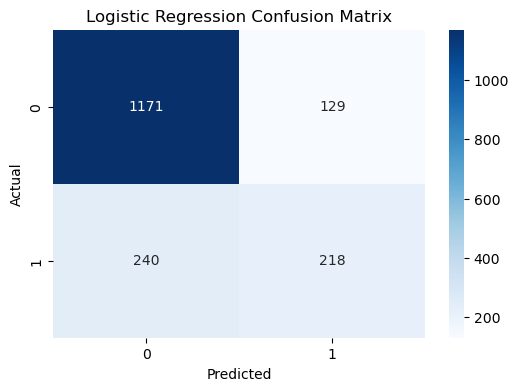

In [147]:
import seaborn as sns
import matplotlib.pyplot as plt

#Plot confusion matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    lr_con,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Observation

The Logistic Regression model was evaluated using accuracy, precision, recall, F1-score, and the confusion matrix. These metrics provide a detailed understanding of the model's ability to correctly classify customers who churned and those who did not.

### Summary

The Logistic Regression model was successfully trained and evaluated using multiple classification metrics. The results obtained from this model will be used as a baseline for comparison with the Random Forest model.

## Random Forest Model

Random Forest is ensemble learning algorithm that combines multiple desicion trees to improve prediction accuracy and reduce overfitting. Unlike Logistic Regression, it can capture complex, non-linear relationships in the data and does not require feature scaling.

In [148]:
# Import Random Foret Model
from sklearn.ensemble import RandomForestClassifier


 

In [149]:
# Create Random Forest model
rf_model= RandomForestClassifier(random_state=42)

# Training model with training dataset

rf_model.fit(x_train,y_train) 

RandomForestClassifier(random_state=42)

In [150]:
# Predict customer churn on the testing dataset

rf_pred= rf_model.predict(x_test)
print(rf_pred[:10])

[0 0 1 0 0 0 0 1 0 0]


### Observation

The Random Forest model was successfully trained using the training dataset. Predictions were generated for the testing dataset and will be evaluated to compare its performance with Logiatic Regression.

## Model Evaluation

The Random Forest model is evaluated using the same metrices as Logistic Regression to ensure a fair comparison.

In [151]:
# Calcualte accuracy of Random Forest model

rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Accuracy:{rf_accuracy:.2%}")

Accuracy:78.44%


In [152]:
# Display precision, recall, F1-score and support
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1300
           1       0.61      0.47      0.53       458

    accuracy                           0.78      1758
   macro avg       0.72      0.68      0.70      1758
weighted avg       0.77      0.78      0.77      1758



In [153]:
# Generate the confusion matrix

rf_con= confusion_matrix(y_test,rf_pred)
print(rf_con)

[[1162  138]
 [ 241  217]]


AttributeError: module 'matplotlib.pyplot' has no attribute 'xlable'

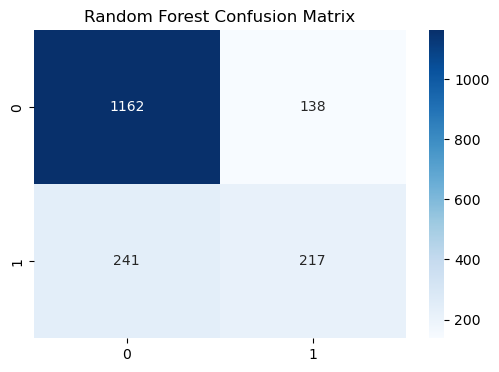

In [156]:
# Plot confusion matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    rf_con,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Random Forest Confusion Matrix")
plt.xlable("Predicted")
plt.ylabel("Actual")
plt.show()

### Obervation

The Random forest model was evaluated using multiple classification metrics. These reults will be compared with Logistic Regression model to determine which algorithm performs better for customer churn prediction.